# Computational Linguistics Class 4: Linear and Logistic Regression
In this class we will work towards getting a intuition of linear regression, logistic regression and test-train splits.
As covered in the lecture, linear regression is a statistical machine learning technique, that predicts a continous number from a set of parameterized variables. We will dive further into what these parameters are, and how to interpret them in this class.

Linear regression is a powerfull tool, but it is important to avoid overfitting. While we can use p-values to check for statistical significance, we need to implement good statistical practices and common sense to avoid overfitting. A tool that helps here is using a test/train split, we will visually explore this concept by implementing a linear regression polynomial.

We will also cover logistic regression, a foundational concept for classification. By applying a sigmoid function on top af a linear regression, we get a regression classification algorithm. that predict the probability of a datapoint belonging to class A or B.

## Part 1: Understanding the parameters of linear regression
It is important to feel comfortable with interpreting the results of a linear regression, before moving on to logistic regressions and neural networks. It is *not important* that you understand the math behind it.

A basic linear regression consists of a few elements: $y = aX + b + \epsilon$

This can be read as: $prediction = slope \cdot feature + intercept + error$

The linear regression algorithm specifically figures out the values of the parameters **a** (slope) and **b** (intercept).

The intercept, *b*, is the predicted value when all features are set to 0. Or the point where our linear regression crosses the y-axis in classic euclidian coordinate system.

The slope, *a*, is the amount our prediction changes, as each time our feature increases by one.

### We will now generate some synthetic data. You have to fit a good linear prediction by changing only the intercept and slope.
You dont need to understand the following code, it just generates the data. You can change the seed to get another dataset.

In [ ]:
# !pip install numpy matplotlib scikit-learn statsmodels datasets ipympl 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

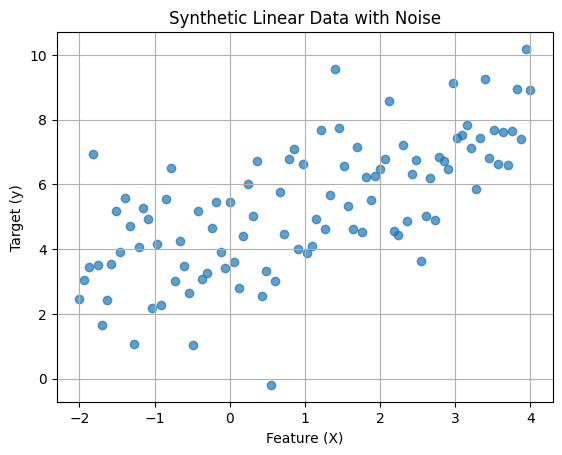

In [85]:
#############################################################################
# Don't change anything below this line. Just run the code to see the plot. #
#############################################################################

# Reproducibility
np.random.seed(8888)

# Random linear parameters
intercept = np.random.uniform(-5, 5)
slope = np.random.uniform(-2, 2)

# Generate feature values and noisy targets
X = np.linspace(-2, 4, 100)
noise = np.random.normal(0, 1.5, size=X.shape)
y = slope * X + intercept + noise

# Plot the scatterplot of the data
plt.scatter(X, y, alpha=0.7)
plt.title('Synthetic Linear Data with Noise')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.grid()
plt.show()

### Change the **a** and **b** parameters in the chunk below to fit a good line to the data. You can use the plot above to visually estimate these parameters.

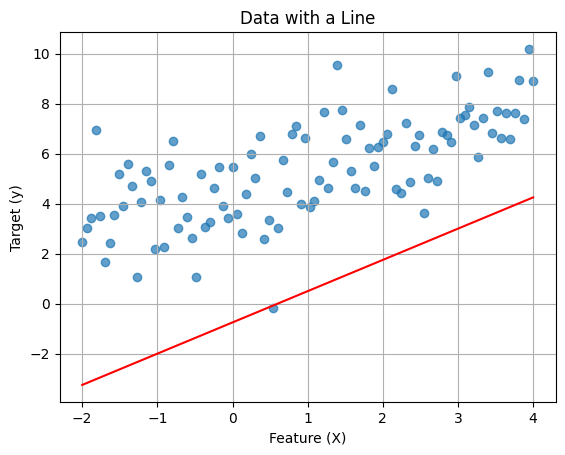

In [86]:
# y = aX + b
a = 1.25
b = -0.75

#############################################################################
# Don't change anything below this line. Just run the code to see the plot. #
#############################################################################

plt.scatter(X, y, alpha=0.7)
plt.plot(X, a * X + b, color='red', label=f'Line: y = {a:.2f}X + {b:.2f}')
plt.title('Data with a Line')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.grid()
plt.show()

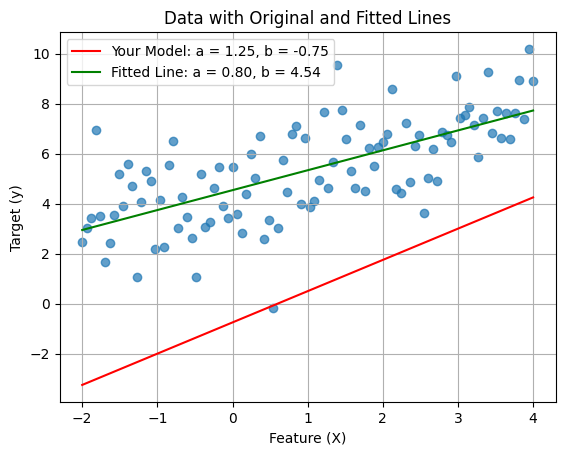

In [87]:
#############################################################################
# Don't change anything below this line. Just run the code to see the plot. #
#############################################################################

# Save data as a pandas DataFrame for statsmodels
data = pd.DataFrame({'X': X, 'y': y})

# Fit the OLS regression model
import statsmodels.formula.api as smf
model = smf.ols(formula='y ~ X', data=data).fit()


# Plot the data and the fitted line
plt.scatter(X, y, alpha=0.7)
plt.plot(X, a * X + b, color='red', label=f'Your Model: a = {a:.2f}, b = {b:.2f}')
plt.plot(X, model.predict(data), color='green', label=f'Fitted Line: a = {model.params["X"]:.2f}, b = {model.params["Intercept"]:.2f}')
plt.title('Data with Original and Fitted Lines')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.legend()
plt.grid()
plt.show()

## Part 2: Multi-parameter models
Fitting a line with a single parameter is all good and handy. But the real world is often more complex. We can expand our model to have more parameters: $y = a_1 X_1 + a_2 X_2 + b + \epsilon$

This follows the same logic as before, but we a now fitting a two-dimensional plane. We can still vizually imagine this. So lets try the same exercise as before, but now with two parameters.

As dimensions/features increase, we aren't able to visually imagine the hyperplane (high dimensional figure), and must trust the math to work it out for us.

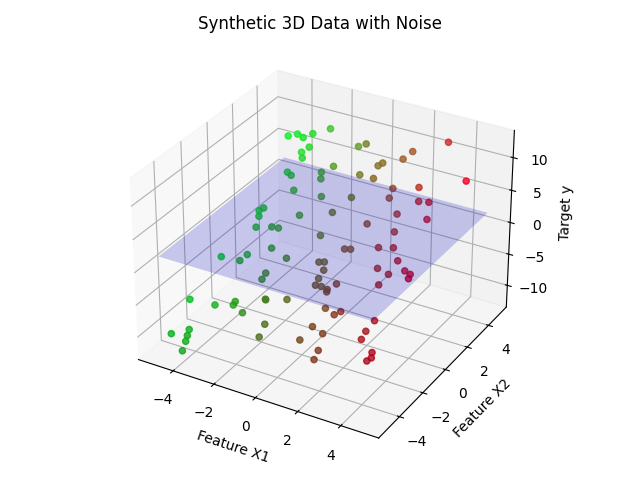

In [88]:
# Your estimates of the 2d-plane parameters (a1, a2, b): Find the best estimate for the plane that fits the data. The plane is defined as: y = a1 * X1 + a2 * X2 + b
a1_estimate = 0
a2_estimate = 0
b_estimate = 2

# Toggle plane visibility (True/False)
show_plane = True
# Change the number for new data to estimate
np.random.seed(787)



#############################################################################
# Don't change anything below this line. Just run the code to see the plot. #
#############################################################################
# Generate synthetic data
num_samples = 100
b_true = np.random.uniform(-3, 3)
a1_true = np.random.uniform(-2, 2)
a2_true = np.random.uniform(-2, 2)

X1 = np.random.uniform(-5, 5, num_samples)
X2 = np.random.uniform(-5, 5, num_samples)
noise = np.random.normal(0, 1, size=num_samples)
y_true = a1_true * X1 + a2_true * X2 + b_true + noise

# Build a 2D color: X1 drives red/green, X2 drives light/dark
X1_norm = (X1 - X1.min()) / (X1.max() - X1.min())  # 0=green, 1=red
X2_norm = (X2 - X2.min()) / (X2.max() - X2.min())  # 0=dark, 1=light

r = X1_norm
g = 1 - X1_norm
b = 0.15 * np.ones(num_samples)
brightness = 0.7 + 0.3 * X2_norm  # scale brightness with X2
colors = np.clip(np.stack([r, g, b], axis=1) * brightness[:, None], 0, 1)

# Plot the data in interactive 3D
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X1, X2, y_true, c=colors, alpha=0.8)

if show_plane:
    # Create a grid for the plane
    x1_grid, x2_grid = np.meshgrid(np.linspace(-5, 5, 20), np.linspace(-5, 5, 20))
    y_grid = a1_estimate * x1_grid + a2_estimate * x2_grid + b_estimate
    ax.plot_surface(x1_grid, x2_grid, y_grid, color='blue', alpha=0.2)

ax.set_title('Synthetic 3D Data with Noise')
ax.set_xlabel('Feature X1')
ax.set_ylabel('Feature X2')
ax.set_zlabel('Target y')
plt.tight_layout()
plt.show()

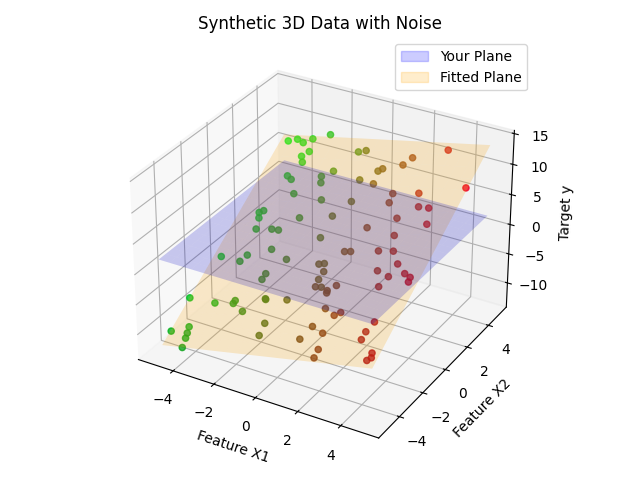

In [89]:
#############################################################################
# Don't change anything below this line. Just run the code to see the plot. #
#############################################################################
# Save data as a pandas DataFrame for statsmodels
data_3d = pd.DataFrame({'X1': X1, 'X2': X2, 'y': y_true})
# Fit the OLS regression model
import statsmodels.formula.api as smf
model_3d = smf.ols(formula='y ~ X1 + X2', data=data_3d).fit()

# Plot the data and the fitted plane and selfmade plane in interactive 3D
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X1, X2, y_true, c=colors, alpha=0.8)


# Create a grid for the plane
x1_grid, x2_grid = np.meshgrid(np.linspace(-5, 5, 20), np.linspace(-5, 5, 20))
y_grid = a1_estimate * x1_grid + a2_estimate * x2_grid + b_estimate
ax.plot_surface(x1_grid, x2_grid, y_grid, color='blue', alpha=0.2)

# Plot the fitted plane from statsmodels
y_fitted_grid = model_3d.params['X1'] * x1_grid + model_3d.params['X2'] * x2_grid + model_3d.params['Intercept']
ax.plot_surface(x1_grid, x2_grid, y_fitted_grid, color='orange', alpha=0.2)

# Legend for planes
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', edgecolor='blue', alpha=0.2, label='Your Plane'),
                   Patch(facecolor='orange', edgecolor='orange', alpha=0.2, label='Fitted Plane')]
ax.legend(handles=legend_elements)

ax.set_title('Synthetic 3D Data with Noise')
ax.set_xlabel('Feature X1')
ax.set_ylabel('Feature X2')
ax.set_zlabel('Target y')
plt.tight_layout()
plt.show()

### Instead of plotting your plane in 3d, we can also make two plots, one of each dimension

Text(0, 0.5, 'Target y')

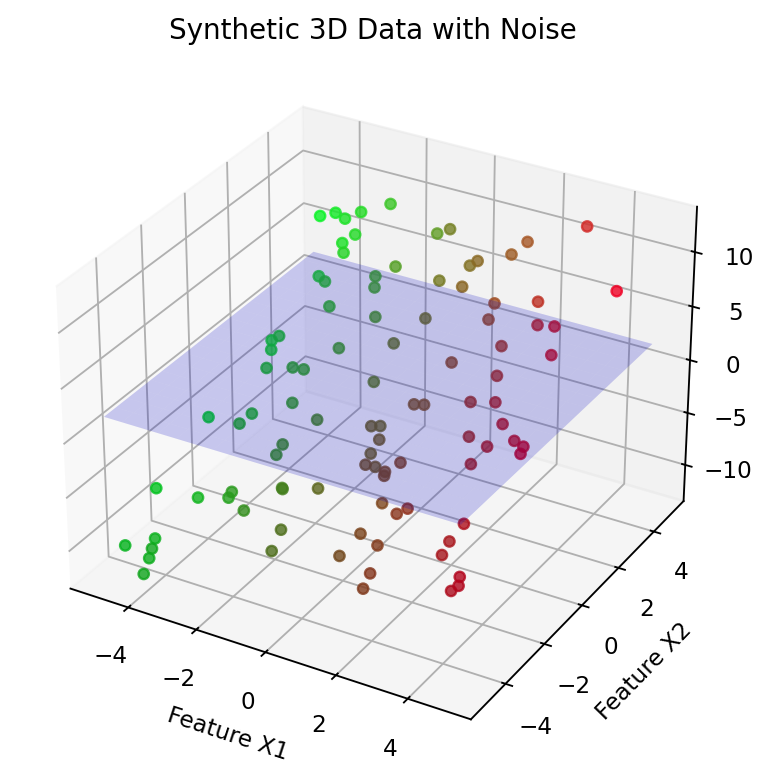

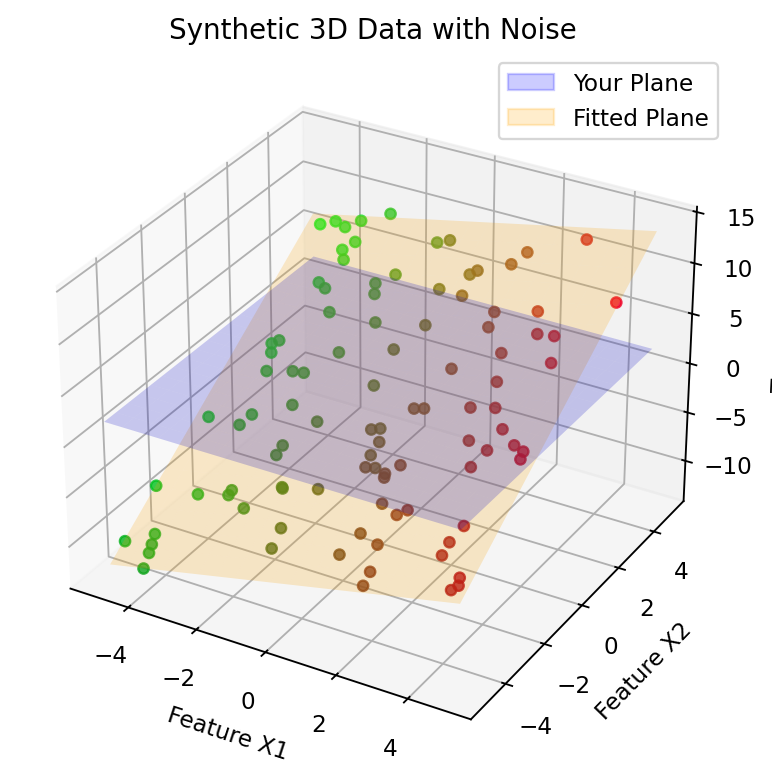

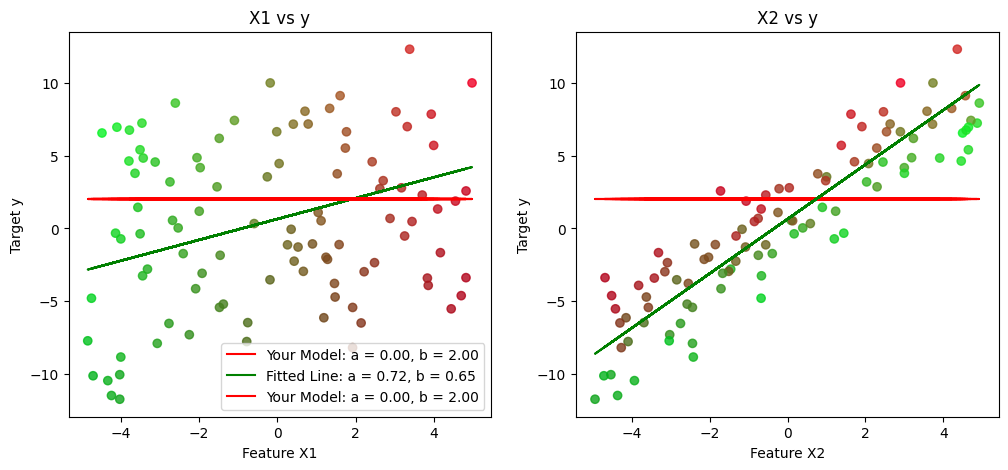

In [90]:
#############################################################################
# Don't change anything below this line. Just run the code to see the plot. #
#############################################################################

# Plot plane in two plots:
%matplotlib inline
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
# Plot 1:
ax1.scatter(X1, y_true, c=colors, alpha=0.8)
# Plot your line for X1
ax1.plot(X1, a1_estimate * X1 + b_estimate, color='red', label=f'Your Model: a = {a1_estimate:.2f}, b = {b_estimate:.2f}')
# Plot the fitted line from statsmodels for X1
ax1.plot(X1, model_3d.params['X1'] * X1 + model_3d.params['Intercept'], color='green', label=f'Fitted Line: a = {model_3d.params["X1"]:.2f}, b = {model_3d.params["Intercept"]:.2f}')
ax1.plot(X1, a1_estimate * X1 + b_estimate, color='red', label=f'Your Model: a = {a1_estimate:.2f}, b = {b_estimate:.2f}')
# Legend for lines
ax1.legend()
ax1.set_title('X1 vs y')
ax1.set_xlabel('Feature X1')
ax1.set_ylabel('Target y')

# Plot 2:
ax2.scatter(X2, y_true, c=colors, alpha=0.8)
# Plot your line for X2
ax2.plot(X2, a2_estimate * X2 + b_estimate, color='red', label=f'Your Model: a = {a2_estimate:.2f}, b = {b_estimate:.2f}')
# Plot the fitted line from statsmodels for X2
ax2.plot(X2, model_3d.params['X2'] * X2 + model_3d.params['Intercept'], color='green', label=f'Fitted Line: a = {model_3d.params["X2"]:.2f}, b = {model_3d.params["Intercept"]:.2f}')
ax2.set_title('X2 vs y')
ax2.set_xlabel('Feature X2')
ax2.set_ylabel('Target y')


## Part 3: Accuracy
As our models become more complex, it becomes harder to visually inspect if they predict the data well.
This is where descriptive statistics become handy.

Lets try and interpret the results of a model:


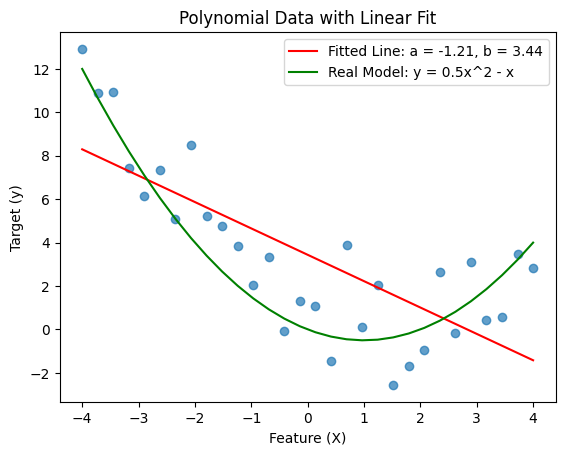

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                     36.00
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.83e-06
Time:                        22:23:36   Log-Likelihood:                -70.738
No. Observations:                  30   AIC:                             145.5
Df Residuals:                      28   BIC:                             148.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4394      0.483      7.116      0.0

In [91]:
#############################################################################
# Don't change anything below this line. Just run the code to see the plot. #
#############################################################################
# Generate data for polynomial data and fit a linear regression model to it:
X_poly = np.linspace(-4, 4, 30)
y =  0.5 * X_poly**2 - X_poly + np.random.normal(0, 2, size=X_poly.shape)

# Save as a dataframe for statsmodels
data_poly = pd.DataFrame({'X': X_poly, 'y': y})
# Fit the OLS regression model
import statsmodels.formula.api as smf
model_poly_sm = smf.ols(formula='y ~ X', data=data_poly).fit()

# Plot the data with the fitted line:
plt.scatter(X_poly, y, alpha=0.7)
# Plot the fitted line from statsmodels for X_poly
plt.plot(X_poly, 
         model_poly_sm.params['X'] * X_poly + model_poly_sm.params['Intercept'], 
         color = 'red', 
         label = f'Fitted Line: a = {model_poly_sm.params["X"]:.2f}, b = {model_poly_sm.params["Intercept"]:.2f}')
# # plot real trend line for reference
plt.plot(X_poly, 0.5 * X_poly**2 - X_poly, color='green', label='Real Model: y = 0.5x^2 - x')
plt.title('Polynomial Data with Linear Fit')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.legend()
plt.show()

# Print the statsmodels output summary for the polynomial data:
print(model_poly_sm.summary())

#### Practice writing a report of the regression results.
Write a short paragraph reporting:
- The form of the linear model, i.e., y ~ X
- The adjusted r squared of the model
- The coefficients of the parameters with their associated p-values.

### Write a report here:



## Part 4: Logistic Regression

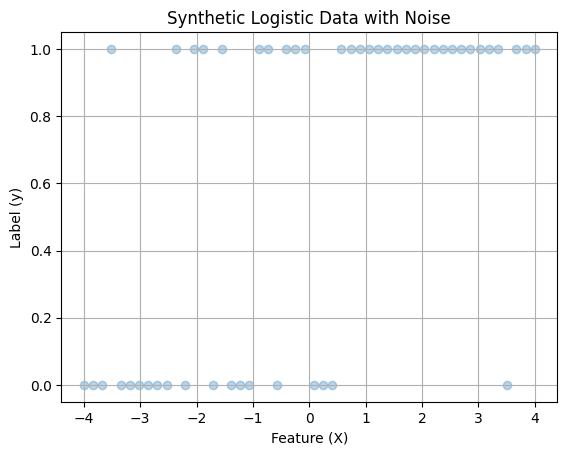

In [92]:
#############################################################################
# Don't change anything below this line. Just run the code to see the plot. #
#############################################################################

# Reproducibility
np.random.seed(8885)

# Random logistic parameters
intercept = np.random.uniform(-3, 3)
slope = np.random.uniform(-3, 3)
error_std = 1.0

# Generate feature values
X = np.linspace(-4, 4, 50)
error = np.random.normal(0, error_std, size=X.shape)

# Compute true probabilities and sample binary labels
log_odds = slope * X + intercept + error  # add noise to the log-odds
p_true = 1 / (1 + np.exp(-log_odds))
y = np.random.binomial(1, p_true)

# Plot the data
plt.scatter(X, y, alpha=0.3, label='Observed labels (0 or 1)')
plt.title('Synthetic Logistic Data with Noise')
plt.xlabel('Feature (X)')
plt.ylabel('Label (y)')
plt.grid()
plt.show()

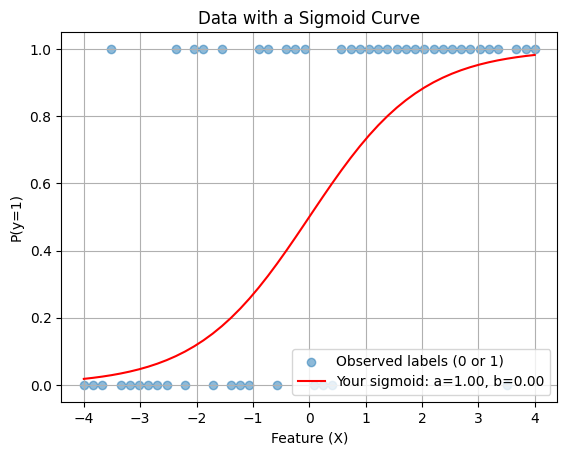

In [93]:
# Adjust these to try to match the data
a = 1.0   # slope of the log-odds
b = 0.0   # intercept of the log-odds

#############################################################################
# Don't change anything below this line. Just run the code to see the plot. #
#############################################################################
p_guess = 1 / (1 + np.exp(-(a * X + b)))

plt.scatter(X, y, alpha=0.5, label='Observed labels (0 or 1)')
plt.plot(X, p_guess, color='red', label=f'Your sigmoid: a={a:.2f}, b={b:.2f}')
plt.title('Data with a Sigmoid Curve')
plt.xlabel('Feature (X)')
plt.ylabel('P(y=1)')
plt.legend()
plt.grid()
plt.show()


Optimization terminated successfully.
         Current function value: 0.472858
         Iterations 6


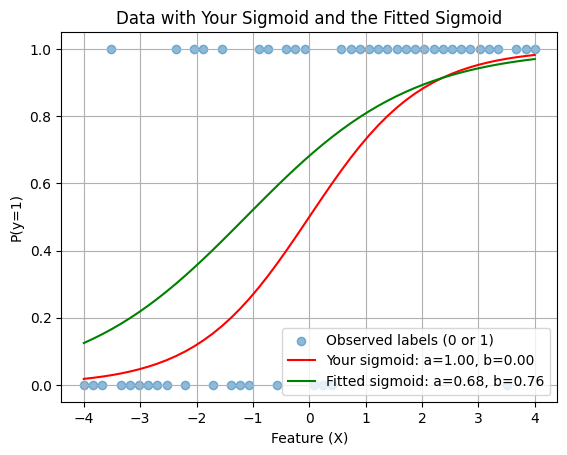

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   50
Model:                          Logit   Df Residuals:                       48
Method:                           MLE   Df Model:                            1
Date:                Mon, 09 Mar 2026   Pseudo R-squ.:                  0.2879
Time:                        22:25:39   Log-Likelihood:                -23.643
converged:                       True   LL-Null:                       -33.203
Covariance Type:            nonrobust   LLR p-value:                 1.227e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7610      0.386      1.972      0.049       0.005       1.517
X              0.6774      0.193      3.509      0.000       0.299       1.056


In [94]:
######################################################################################
# Don't change anything below this line. Just run the code to see the model summary. #
######################################################################################

# Save data as a pandas DataFrame for statsmodels
data = pd.DataFrame({'X': X, 'y': y})

# Fit the logistic regression model
import statsmodels.formula.api as smf
model = smf.logit(formula='y ~ X', data=data).fit()

# Compute fitted probabilities
p_fitted = model.predict(data)
p_guess   = 1 / (1 + np.exp(-(a * X + b)))

# Plot data, your guess, and the fitted curve
plt.scatter(X, y, alpha=0.5, label='Observed labels (0 or 1)')
plt.plot(X, p_guess,  color='red',   label=f'Your sigmoid: a={a:.2f}, b={b:.2f}')
plt.plot(X, p_fitted, color='green', label=f'Fitted sigmoid: a={model.params["X"]:.2f}, b={model.params["Intercept"]:.2f}')
plt.title('Data with Your Sigmoid and the Fitted Sigmoid')
plt.xlabel('Feature (X)')
plt.ylabel('P(y=1)')
plt.legend()
plt.grid()
plt.show()

print(model.summary())

### What does this output have in common with a linear regression?

## Part 5: Sentiment Classification:
A classic application for logistic regression and TF-IDF matrices is sentiment classification. 
By transforming sentences into TF-IDF weighted matrices, we can get a numeric representation of text.
Before LLMs became common, logistic TF-IDF regression was the industry standard for sentiment classification.

We will train a model on a dataset consisting of movie reviews from IMDB. 
Ratings below three has been labeled as Negative (0). 
Ratings above 7 has been labeled as Positive (1).

The following three chunks of code does the following:
1. Load the IMDB dataset and show the head()
2. Load the TF-IDF vectorizer from the sklearn library and embed the dataframe.
3. Fit the logistic regression, get accuracy on test-set, and plot most important terms.

> **Load the data:**

In [ ]:
##################################################################################
# Don't change anything below this line. Just run the code to see the dataframe. #
##################################################################################
from sklearn.datasets import load_files
from datasets import load_dataset
import pandas as pd
import numpy as np

# Load a subsample of IMDB reviews
dataset = load_dataset("imdb", split="train").shuffle(seed=8888).select(range(2500))
df = pd.DataFrame({'text': dataset['text'], 'sentiment': dataset['label']})

print(f"Class balance: {df['sentiment'].value_counts().to_dict()}")

df.head()

Class balance: {1: 1258, 0: 1242}


,text,sentiment
0,This movie is the worst movie i have ever seen...,0
1,"As usual, Hollywood stereotyped EVERYONE in th...",1
2,One of my favourite films first saw it when I ...,1
3,This film caught me off guard when it started ...,1
4,I registered just to make this comment (which ...,0


> **Vectorize with TF-IDF function:**

In [ ]:
#############################################################################
# Don't change anything below this line. Just run the code to see the results. #
#############################################################################
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,1))
X_tfidf = vectorizer.fit_transform(df['text'])
y = df['sentiment'].values

# Inspect the shape of the TF-IDF matrix
print(f"Matrix shape: {X_tfidf.shape}")
print(f"({X_tfidf.shape[0]} reviews × {X_tfidf.shape[1]} vocabulary terms)\n")

# Inspect TF-IDF scores for a single review
sample_vec = X_tfidf[0]
feature_names = vectorizer.get_feature_names_out()
scores = pd.Series(sample_vec.toarray()[0], index=feature_names)
print("Top 10 TF-IDF terms in first review:")
print(scores.nlargest(10).round(3))

> **Fit logistic regression:**

(this is a little different syntax for the logistic regression. It takes takes a X_train, and Y_train as input)
```python
model = sm.Logit(y_train, X_train_dense)
result = model.fit(method='lbfgs', maxiter=1000, disp=False)
```

In [ ]:
#############################################################################
# Don't change anything below this line. Just run the code to see the plot. #
#############################################################################
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=8888)

# statsmodels expects a dense array — subsample features to keep it manageable
n_features = 5000
top_feature_idx = np.argsort(np.asarray(X_tfidf.sum(axis=0)).flatten())[-n_features:]
top_feature_names = feature_names[top_feature_idx]

X_train_dense = sm.add_constant(X_train[:, top_feature_idx].toarray())
X_test_dense  = sm.add_constant(X_test[:, top_feature_idx].toarray())

model = sm.Logit(y_train, X_train_dense)
result = model.fit(method='lbfgs', maxiter=1000, disp=False)

# Evaluate
y_pred = (result.predict(X_test_dense) >= 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Plot top positive and negative coefficient words (excluding the intercept)
coefs = pd.Series(result.params[1:], index=top_feature_names)
top_pos = coefs.nlargest(15)[::-1]  # reverse for plotting
top_neg = coefs.nsmallest(15)
top_words = pd.concat([top_neg, top_pos])

colors = ['tomato'] * 15 + ['steelblue'] * 15
plt.figure(figsize=(8, 8))
plt.barh(top_words.index, top_words.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Positive and Negative Coefficient Words')
plt.xlabel('Logistic Regression Coefficient')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

## Part 6: Investigate how the model works (and importantly fails)
To identify how the model works, it can be usefull to test some examples.
We can often find interesting examples by looking at misclassified sentences.
I have written som sentences below, that we can use to test our model.
Logistic TF-IDF models can only look at individual words.

This chunk of code creates a string that outputs:
1. The sentiment classification.
2. The probability of it being that classification.
3. The sentence

In [ ]:
# Test predictions on multiple reviews
new_reviews = [
    "I did not like this movie at all. I can't get myself to say anything good about it.",
    "I loved this movie. I only have good things to say about it.",
    "I hated this movie. The acting was horrible.",
    "Good Good Good Good Bad",
    "Good Good Good Good Good Good Good Good Bad",
]
################################################################################
# Don't change anything below this line. Just run the code to see the results. #
################################################################################

# Transform new reviews using the same vectorizer and feature subset
new_vecs = vectorizer.transform(new_reviews)[:, top_feature_idx].toarray()

# Add intercept term to new_vecs and predict the probability of being positive
new_vecs = np.hstack([np.ones((new_vecs.shape[0], 1)), new_vecs])  # prepend intercept column
pred_probs = result.predict(new_vecs)
pred_logits = np.log(pred_probs / (1 - pred_probs))
# Print predictions
for review, prob, logit in zip(new_reviews, pred_probs, pred_logits):
    sentiment = "Positive" if prob >= 0.5 else "Negative"
    print(f"{sentiment} ({prob:.4f} | {logit:.4f}): {review}")

## Creating a logit lens
A tool popuralized by LLM interpretability research is the logit lens.
It shows the effect of that token has on a logistic function, i.e. the parameter associated with each TF-IDF activation.
You dont need to understand the code. But play around with some different sentences to get an understanding of the models behaviour.

In [ ]:
### You don't need to understand every line of code below. But have a look at the visualization in the next chunk.
##################################################################################
# Don't change anything below this line. Just run the code to load the function. #
##################################################################################
def logit_lens(review):
    # Get TF-IDF weights for each unique token
    tokens        = list(dict.fromkeys(vectorizer.build_analyzer()(review)))
    sample_vec    = vectorizer.transform([review])[:, top_feature_idx].toarray()[0]
    tfidf_weights = pd.Series(sample_vec, index=top_feature_names)

    # Build the deduplicated DataFrame
    df_lens = pd.DataFrame({
        'token':     tokens,
        'parameter': [get_weight(token) for token in tokens],
        'tfidf':     [tfidf_weights.get(token, 0.0) for token in tokens],
    })
    df_lens['contribution'] = df_lens['parameter'] * df_lens['tfidf']
    print(df_lens.round(4))

    # Whitespace tokenization to preserve original word order and repeats
    raw_tokens = review.split()

    # Assign contribution on first occurrence only, zero for repeats
    seen = set()
    contributions = []
    for token in raw_tokens:
        token_lower = token.strip(".,!?'\"").lower()
        if token_lower not in seen:
            seen.add(token_lower)
            match = df_lens.loc[df_lens['token'] == token_lower, 'contribution']
            contributions.append(float(match.values[0]) if len(match) else 0.0)
        else:
            contributions.append(0.0)

    token_df = pd.DataFrame({'token': raw_tokens, 'contribution': contributions})
    token_df['cum_logit'] = result.params[0] + token_df['contribution'].cumsum()
    token_df['cum_prob']  = 1 / (1 + np.exp(-token_df['cum_logit']))

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x      = range(len(token_df))
    labels = token_df['token']

    axes[0].plot(x, token_df['cum_logit'], marker='o')
    axes[0].set_title('Cumulative Logit as Review Unfolds')
    axes[0].set_xlabel('Token')
    axes[0].set_ylabel('Cumulative Logit')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=90)
    axes[0].grid()

    axes[1].plot(x, token_df['cum_prob'], marker='o', color='orange')
    axes[1].set_title('Cumulative Probability as Review Unfolds')
    axes[1].set_xlabel('Token')
    axes[1].set_ylabel('Cumulative Probability')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=90)
    axes[1].grid()

    plt.suptitle(f'"{review[:60]}..."', fontsize=11)
    plt.tight_layout()
    plt.show()

In [ ]:
# Try a running the function with a few different reviews to get a feeling of the model.
logit_lens("I did not like this movie at all. I can't get myself to say anything good about it.")